In [1]:
# import sys
# import random
# import csv
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import torch.nn.functional as F
# import pandas as pd
# import json
# from esm.models.esmc import ESMC
# from esm.sdk.api import ESMProtein, LogitsConfig
# from sklearn.model_selection import train_test_split
# import argparse

In [2]:
name_of_model = 'Name'
blocks_unfrozen = 1
base_block_lr = 0.001
regression_block_lr = 0.01
HLA = 'HLAA0201'
encoding = 'epitope'

In [3]:
device = 'gpu'

In [4]:
# #########################################################
# # Model Definition: ESMCMasked
# #########################################################
# class ESMCMasked(nn.Module):
#     """
#     A wrapper that takes a pre-trained ESM C model and adds
#     a masking (language modeling) head on top of the final hidden states.
#     This version expects batched input_ids and attention_mask in forward.
#     """
#     def __init__(self, base_model, hidden_dim=960, num_aa=33):
#         super().__init__()
#         self.base_model = base_model  # Pretrained ESM C model
#         self.mask_head = nn.Linear(hidden_dim, num_aa)  # Simple linear LM head

#     def forward(self, input_ids, attention_mask=None):
#         """
#         Args:
#           input_ids: [batch_size, seq_len] integer tokens
#           attention_mask: [batch_size, seq_len], 1 for real tokens, 0 for padding
#         Returns:
#           out_logits: [batch_size, seq_len, num_aa]
#         """
#         # 1) ESM forward
#         #    If your ESM model supports input_ids directly (like a HuggingFace model),
#         #    do something like:
#         outputs = self.base_model.forward(input_ids )
#         # outputs.hidden_states[-1]: [batch_size, seq_len, hidden_dim]
#         hidden_states = outputs.hidden_states[-1].to(torch.float32) # ensure float32

#         # 2) Pass through the custom LM head
#         out_logits = self.mask_head(hidden_states)  # [batch_size, seq_len, num_aa]
#         return out_logits

# ##################################################
# # 3. Load the base ESM C model and wrap it
# ##################################################
# print("Loading pretrained ESM_Cambrian model...", flush = True)
# base_model = ESMC.from_pretrained("esmc_300m").to(device)

# # Create our extended masked model
# model_masked = ESMCMasked(base_model, hidden_dim=960, num_aa=33).to(device)

# def load_model(model_path, device='gpu'):
#     # Load checkpoint
#     checkpoint = torch.load(model_path, map_location=device)
#     config = checkpoint['config']
    
#     # 1. Load base ESMC model
#     base_model = ESMC.from_pretrained("esmc_300m").to(device)
    
#     # 3. Wrap with ESMCMasked using saved config
#     model = ESMBA(
#         base_model,
#     ).to(device)
    
#     # 4. Load trained weights
#     state_dict = checkpoint['model_state_dict']

#     # Remove keys corresponding to the old mask head
#     state_dict = {k: v for k, v in state_dict.items()}
    
#     model.load_state_dict(state_dict, strict=False)
    
#     return model


# # if not torch.cuda.is_available():
# #     print("CUDA is not available. Exiting.")
# #     sys.exit(1)

# device = torch.device("gpu")
# print(f"Using device: {device}", flush=True)

# full_pretraining = False  # Simplified boolean conversion
# name_of_model = "RUN2"
# encoding = 'epitope'
# # file_path = '/global/scratch/users/sergiomar10/models/esm_c/masking/HLA-0201_epitope_only/False-Full_pretraining_2000_seq_AUG_3.pt'
# file_path = '/global/scratch/users/sergiomar10/models/esm_c/masking/ALLHLAs_epitope_only/False-Full_pretraining_100000_seq_AUG_3_ALL_HLAS.pt'

# # model = load_model(
# #     file_path,  # Must match training setting!
# #     device=device
# # )

# # base_model = model.base_model

In [5]:
import numpy as np
import os
import sys
import json
import random
import csv
import argparse

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import pandas as pd
from sklearn.model_selection import train_test_split

from torch.utils.data import Dataset, DataLoader
from esm.models.esmc import ESMC

#########################################################
# Model Definition: ESMCMasked
#########################################################
class ESMCMasked(nn.Module):
    """
    A wrapper that takes a pre-trained ESM C model and adds
    a masking (language modeling) head on top of the final hidden states.
    This version expects batched input_ids and attention_mask in forward.
    """
    def __init__(self, base_model, hidden_dim=960, num_aa=33):
        super().__init__()
        self.base_model = base_model  # Pretrained ESM C model
        self.mask_head = nn.Linear(hidden_dim, num_aa)  # Simple linear LM head

    def forward(self, input_ids, attention_mask=None):
        """
        Args:
          input_ids: [batch_size, seq_len] integer tokens
          attention_mask: [batch_size, seq_len], 1 for real tokens, 0 for padding
        Returns:
          out_logits: [batch_size, seq_len, num_aa]
        """
        # 1) ESM forward
        #    If your ESM model supports input_ids and attention_mask directly:
        outputs = self.base_model(
            input_ids,
            # attention_mask=attention_mask  ### FIX: pass attention_mask if supported
        )
        
        # outputs.hidden_states[-1]: [batch_size, seq_len, hidden_dim]
        hidden_states = outputs.hidden_states[-1].to(torch.float32)

        # 2) Pass through the custom LM head
        out_logits = self.mask_head(hidden_states)  # [batch_size, seq_len, num_aa]
        return out_logits

#########################################################
# Load the Base ESM C Model
#########################################################
print("Loading pretrained ESM_Cambrian model...", flush=True)
base_model = ESMC.from_pretrained("esmc_300m").to('cuda')

# Create our extended masked model
model_masked = ESMCMasked(base_model, hidden_dim=960, num_aa=33).to('cuda')


Loading pretrained ESM_Cambrian model...


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

In [6]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [7]:

#########################################################
# Unfreeze Last N Blocks
#########################################################
last_block_params = []
total_blocks = 30  # Adjust if your ESM model has a different # of blocks
min_range = total_blocks - blocks_unfrozen
for block_idx in range(min_range, total_blocks):
    last_block_params.extend(
        list(model_masked.base_model.transformer.blocks[block_idx].parameters())
    )
# Also unfreeze final layer norm
norm_params = list(model_masked.base_model.transformer.norm.parameters())
last_block_params.extend(norm_params)

#########################################################
# Optimizer and Loss
#########################################################
optimizer = optim.Adam(
    [
        {"params": last_block_params, "lr": base_block_lr},
        {"params": model_masked.mask_head.parameters(), "lr": regression_block_lr},
    ],
    weight_decay=1e-5
)

# Note: We ignore pad_token_id in the loss so only masked tokens are trained
criterion = nn.CrossEntropyLoss(ignore_index=model_masked.base_model.tokenizer.pad_token_id)

#########################################################
# Standard AA Mappings (for reference/logging)
#########################################################
amino_acids = "ARNDCEQGHILKMFPSTWYV"
aa_to_idx = {
    aa: base_model.tokenizer(text=aa).input_ids[1]  # index=1 to skip <cls> token
    for aa in amino_acids
}
idx_to_aa = {idx: aa for aa, idx in aa_to_idx.items()}
print(f"aa_to_idx: {aa_to_idx}", flush=True)
print(f"idx_to_aa: {idx_to_aa}", flush=True)

#########################################################
# FASTA Parser
#########################################################
def parse_fasta(file_path):
    sequences = []
    with open(file_path, 'r') as f:
        header = None
        seq = ""
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if seq:
                    sequences.append((header, seq))
                    seq = ""
                header = line[1:]
            else:
                seq += line
        if seq:
            sequences.append((header, seq))
    return sequences

#########################################################
# Load HLA Sequences
#########################################################
fasta_path = "/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/other/hla_sequences.fasta"
hla_data = parse_fasta(fasta_path)

hla_sequences = [
    seq for header, seq in hla_data
    if header.replace(':','').replace('*','') == HLA.replace("HLA", "")
][0]

print(f"Loaded {len(hla_sequences)} HLA sequences from {fasta_path}", flush=True)


aa_to_idx: {'A': 5, 'R': 10, 'N': 17, 'D': 13, 'C': 23, 'E': 9, 'Q': 16, 'G': 6, 'H': 21, 'I': 12, 'L': 4, 'K': 15, 'M': 20, 'F': 18, 'P': 14, 'S': 8, 'T': 11, 'W': 22, 'Y': 19, 'V': 7}
idx_to_aa: {5: 'A', 10: 'R', 17: 'N', 13: 'D', 23: 'C', 9: 'E', 16: 'Q', 6: 'G', 21: 'H', 12: 'I', 4: 'L', 15: 'K', 20: 'M', 18: 'F', 14: 'P', 8: 'S', 11: 'T', 22: 'W', 19: 'Y', 7: 'V'}
Loaded 365 HLA sequences from /global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/other/hla_sequences.fasta


In [8]:
# import pandas as pd
# IEDB_full = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/IEDB_subseted_HLA_w_BA_full_for_training.csv.gz',
#                         sep=',', header=0)
                        

In [9]:
# IEDB_full['MHC Restriction - Name'].unique()

In [10]:
# IEDB_full_subset = IEDB_full[IEDB_full['MHC Restriction - Name'] == 'HLAB5701']
# IEDB_full_subset = IEDB_full_subset[IEDB_full_subset['Assay - Qualitative Measurement'].str.contains('Positive')]

# peptides = IEDB_full_subset['Epitope - Name'].unique()
# # set max columns
# pd.set_option('display.max_columns', None)


In [11]:
aa = []

for x in peptides:
    if '+' in x:
        continue
    for y in x:
        aa.append(y)

NameError: name 'peptides' is not defined

In [ ]:
peptides

array(['KMKEIAEAY', 'FAFVTDNTY', 'YTAVVPLVY', ..., 'FAWPGASSW',
       'QSAQAQAQTGW', 'KAMRPWQSF'], dtype=object)

In [ ]:
print(f'{27093 / len(aa) * 100 }%')

11.899386869520914%


<Axes: xlabel='0'>

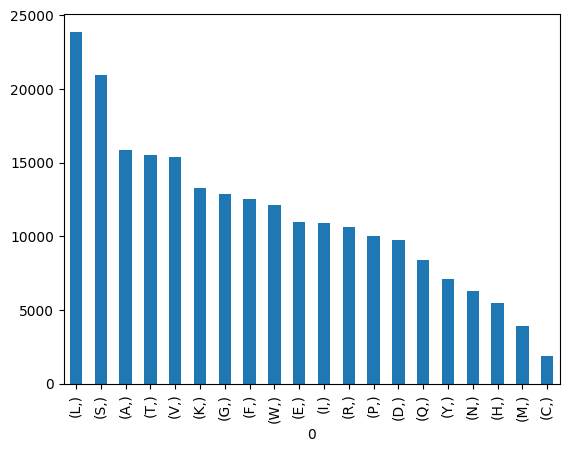

In [ ]:
pd.DataFrame(aa).value_counts().plot(kind='bar')

In [ ]:
results_df2[results_df2['']]

,epitope,position,ground_truth_id,predicted_id,predicted_prob,true_token_prob
0,SLYGASPGL,0,8,2,1.000000,0.000000
1,SLYGASPGL,1,4,2,1.000000,0.000000
2,SLYGASPGL,2,19,2,1.000000,0.000000
3,SLYGASPGL,6,14,2,1.000000,0.000000
4,FQNPQTHVIEN,4,16,2,1.000000,0.000000
...,...,...,...,...,...,...
10003,APGAPGPKAA,7,15,2,1.000000,0.000000
10004,APGAPGPKAA,10,2,2,0.999978,0.999978
10005,SILSNIHEV,2,4,2,0.999673,0.000000
10006,SILSNIHEV,4,17,2,1.000000,0.000000


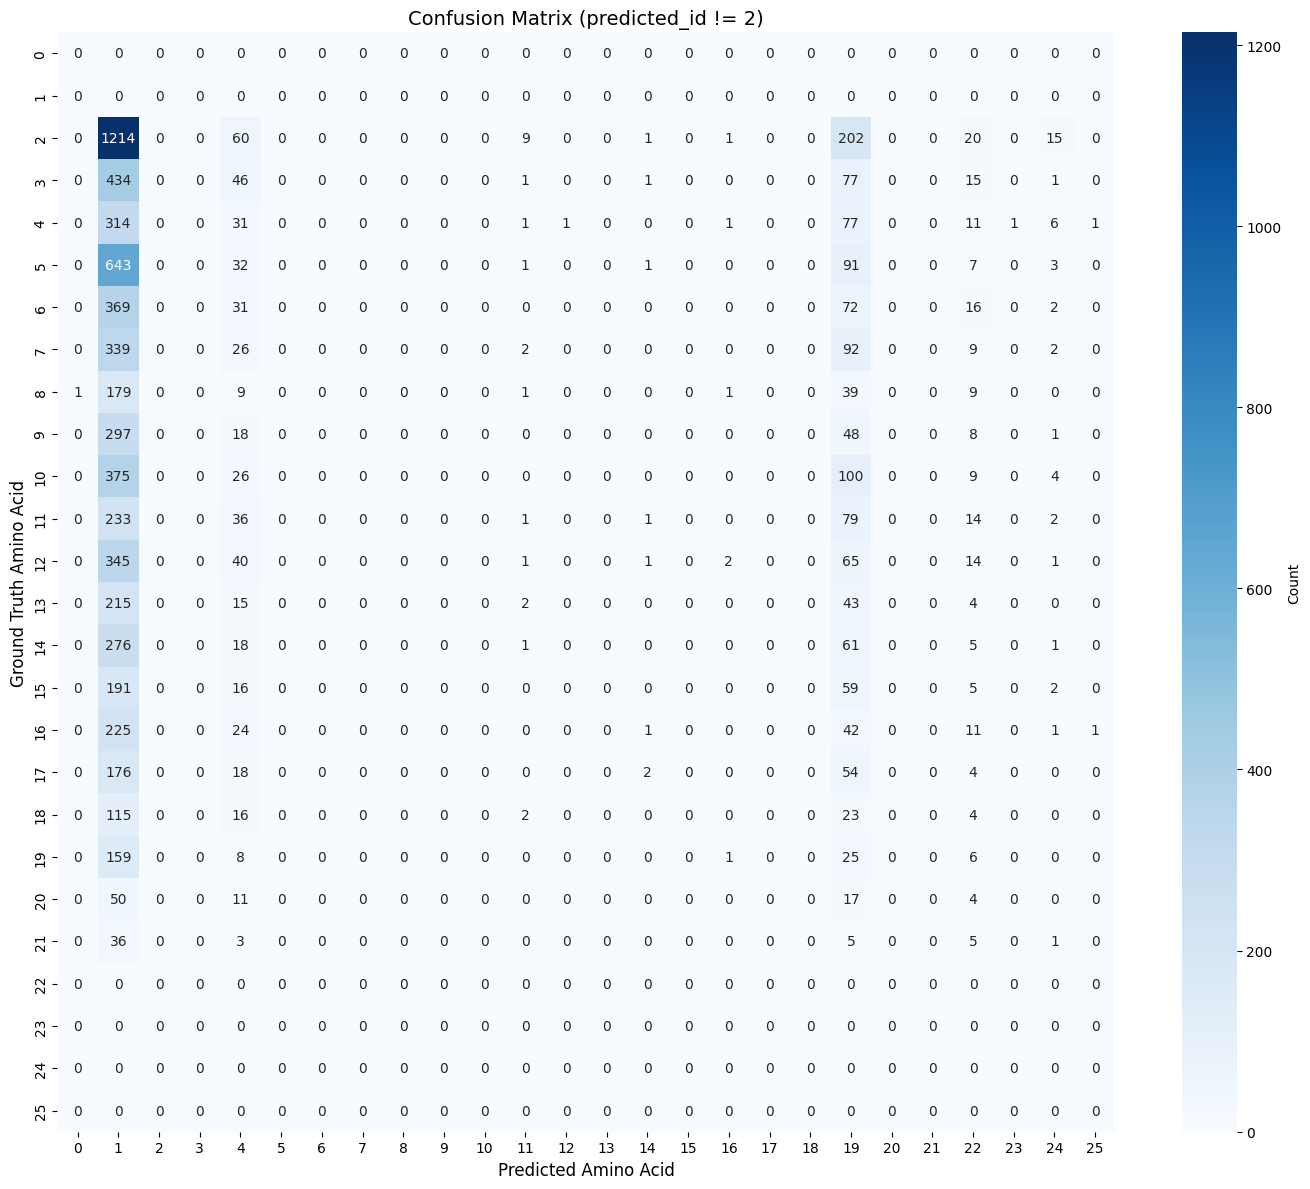

In [ ]:
# Counter(aa)
results_df2 = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/A0201_Mask_eval_OUTOFBOX.csv')
results_df2[results_df2['predicted_id'] != 4]
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Your filtered data
filtered_df = results_df2[(results_df2['ground_truth_id'] > 3) & (results_df2['position'] != 0)]

# Create mapping from token ID to amino acid
# If vocab is {token: id}, we need to invert it to {id: token}
# if isinstance(base_model.tokenizer.vocab, dict):
#     id_to_aa = {v: k for k, v in base_model.tokenizer.vocab.items()}
# else:
#     # If it's already a list/array where index = id
#     id_to_aa = {i: aa for i, aa in enumerate(base_model.tokenizer.vocab)}

# Get unique labels
gt_ids = sorted(filtered_df['ground_truth_id'].unique())
pred_ids = sorted(filtered_df['predicted_id'].unique())
all_ids = sorted(set(gt_ids) | set(pred_ids))

# Map IDs to amino acids
# labels = [id_to_aa.get(i, f'ID_{i}') for i in all_ids]

# Create confusion matrix
cm = confusion_matrix(filtered_df['ground_truth_id'], 
                     filtered_df['predicted_id'],
                     labels=all_ids)

# Plot
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            # xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Amino Acid', fontsize=12)
plt.ylabel('Ground Truth Amino Acid', fontsize=12)
plt.title('Confusion Matrix (predicted_id != 2)', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# from collections import Counter
# Counter(aa)

In [ ]:
df = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/A0201_eval_epitopes_confusion_matrix.csv')
df

,epitope,position
0,SLYGASPGL,0
1,SLYGASPGL,1
2,SLYGASPGL,2
3,SLYGASPGL,6
4,FQNPQTHVIEN,4
...,...,...
10884,APGAPGPKAA,10
10885,SILSNIHEV,2
10886,SILSNIHEV,4
10887,SILSNIHEV,10


In [ ]:
class PositionSpecificDataset(Dataset):
    """Dataset that masks specific positions in epitopes, with optional HLA prefix."""
    
    def __init__(self, epitopes, positions, base_model, hla_sequence=None, 
                 max_length=400, include_hla=True):
        """
        Args:
            epitopes: List or array of epitope sequences
            positions: List or array of positions to mask (relative to epitope, not full sequence)
            base_model: The base model with tokenizer
            hla_sequence: HLA sequence to prepend (e.g., "MAVMAPRTLVL...")
            max_length: Maximum sequence length for tokenization
            include_hla: Whether to prepend HLA sequence
        """
        self.epitopes = epitopes
        self.positions = positions
        self.tokenizer = base_model.tokenizer
        self.max_length = max_length
        self.hla_sequence = hla_sequence if include_hla else ""
        self.hla_length = len(self.hla_sequence) if self.hla_sequence else 0
        self.pad_id = self.tokenizer.pad_token_id
        self.mask_id = self.tokenizer.mask_token_id
        
    def __len__(self):
        return len(self.epitopes)
    
    def __getitem__(self, idx):
        epitope = self.epitopes[idx]
        position_to_mask = self.positions[idx]
        
        # 1. Create full sequence (HLA + epitope)
        if self.hla_sequence:
            full_sequence = self.hla_sequence + epitope
        else:
            full_sequence = epitope
        
        # 2. Encode the full sequence
        encoding = self.tokenizer(
            full_sequence,
            return_tensors='pt',
            padding='max_length',
            truncation=True,
            max_length=self.max_length
        )
        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)
        
        # 3. Mask the specific position in the EPITOPE part
        masked_input_ids, labels = self.mask_epitope_position(
            input_ids, position_to_mask
        )
        
        # 4. Return epitope only (without HLA) for output tracking
        return masked_input_ids, attention_mask, labels, epitope, position_to_mask
    
    def mask_epitope_position(self, input_ids, epitope_position):
        """
        Mask a specific position in the epitope part of the sequence.
        
        Args:
            input_ids: Tokenized full sequence (HLA + epitope)
            epitope_position: Position relative to the START of the epitope (0-indexed)
        """
        labels = torch.full_like(input_ids, self.pad_id)
        
        # Find non-pad positions
        nonpad_positions = (input_ids != self.pad_id).nonzero(as_tuple=True)[0]
        if len(nonpad_positions) == 0:
            return input_ids, labels
        
        # Calculate actual position in the full tokenized sequence
        # Position = <cls> (1 token) + HLA length + epitope position
        actual_position = 1 + self.hla_length + epitope_position
        
        # Check if position is valid and within non-padded region
        if actual_position < len(input_ids) and input_ids[actual_position] != self.pad_id:
            # Store the original token in labels
            labels[actual_position] = input_ids[actual_position]
            # Mask the token
            input_ids[actual_position] = self.mask_id
        
        return input_ids, labels


def position_collate_fn(batch):
    """Collate function for position-specific dataset."""
    input_ids_list, attn_masks_list, labels_list, epitopes_list, positions_list = zip(*batch)
    
    input_ids = torch.stack(input_ids_list, dim=0)
    attention_mask = torch.stack(attn_masks_list, dim=0)
    labels = torch.stack(labels_list, dim=0)
    
    return input_ids, attention_mask, labels, list(epitopes_list), list(positions_list)


def get_position_specific_dataloader(df, base_model, hla_sequence=None, 
                                     batch_size=8, max_length=400, include_hla=True):
    """
    Create a dataloader from a DataFrame with 'epitope' and 'position' columns.
    
    Args:
        df: DataFrame with 'epitope' and 'position' columns
        base_model: The base model with tokenizer
        hla_sequence: HLA sequence string to prepend
        batch_size: Batch size
        max_length: Maximum sequence length (should accommodate HLA + epitope)
        include_hla: Whether to include HLA sequence in encoding
    """
    epitopes = df['epitope'].values
    positions = df['position'].values
    
    dataset = PositionSpecificDataset(
        epitopes=epitopes,
        positions=positions,
        base_model=base_model,
        # hla_sequence=hla_sequence,
        max_length=max_length,
        # include_hla=include_hla
    )
    
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=position_collate_fn
    )
    
    return loader

In [ ]:
np.random.randint(1,33,1)

array([19])

In [ ]:
def make_sequences():
    seq = 'M'
    for i in range(250):
        aa = [x for x in base_model.tokenizer.vocab.keys()][np.random.randint(1,33,1)[0]]
        if '<' not in aa and '-' not in aa and '|' not in aa:
            seq += aa

    return seq

seq = []
for i in range(60):
    seq.append(make_sequences())

In [ ]:
break

In [ ]:

df = pd.DataFrame()    
df['epitope'] = seq
df['position'] = 0
df

,epitope,position
0,MOVILZFLBKZQFPITLFHKZLRRTFPBMUTYCBQLHRDGCMOSDP...,0
1,MZHKLPERKSSQZDYVKHSUPKSVAEWSIOTQFNQAFUKMRFFHLE...,0
2,MMIFZNDLPIYSZXITIHZNALUVZPRDBPZSWQRUEFANTRCCDL...,0
3,MWIEFMNQOCZQZYAKWKBSMMCUBQGYTAPTVSTGLPTGHTTHIN...,0
4,MNZGQCXXAYYZQGDDFFABLRQQZVXHQSIEPNVXQYOVZOYROB...,0
5,MRGTXCGDENDOSMIVIIZIFTRUKORYNMSAKZWLQSCCYFKGBW...,0
6,MGWPSQLSZQGYLABIRTNUCYNMOXLFDSGBGBKPAWPFLWWXTB...,0
7,MKQMBRDYOMWTDMXNLDXPKUBUQGMFKIMHRKCGHKQGRITAVH...,0
8,MFEKMGLSFEAQGKIUZVGZRAWWIYWZDLOURSNMPAPEUEWPTY...,0
9,MNRQYHCNZBQBKORIXYCPZXAWCYSOIYIGUSQVAALLVVHSHY...,0


In [ ]:

# Create dataloader with HLA sequence
eval_loader = get_position_specific_dataloader(
    df=df,
    base_model=model_masked.base_model,
    # hla_sequence=hla_sequences,  # Add HLA sequence
    batch_size=32,
    max_length=500,  # Larger to accommodate HLA + epitope
    include_hla=False  # Set to False if you don't want HLA
)

# Evaluate - outputs will only contain epitopes (no HLA)
model_masked.eval()
results = []

In [ ]:
device = 'cuda'
total_samples = len(df)
processed = 0
print(f"Starting evaluation on {total_samples} samples...")
print("=" * 60)
with torch.no_grad():
    for batch_idx, (input_ids, attention_mask, labels, epitopes, positions) in enumerate(eval_loader):
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)
        # Get predictions (model sees HLA + epitope)
        logits = model_masked(input_ids, attention_mask)
        probs = F.softmax(logits, dim=-1)
        # Process each sample in the batch
        for b in range(input_ids.size(0)):
            epitope = epitopes[b] # This is ONLY the epitope (no HLA)
            position = positions[b]
            # Find the masked position
            mask = (labels[b] != model_masked.base_model.tokenizer.pad_token_id)
            if mask.any():
                ground_truth_id = labels[b][mask][0].item()
                pred_probs = probs[b][mask][0]
                pred_id = torch.argmax(pred_probs).item()
                # Get top 2 predictions
                top2 = torch.topk(pred_probs, 2)
                # predictions_all = pred_probs
                results.append({
                    'epitope': epitope, # Saved WITHOUT HLA
                    'position': position,
                    'ground_truth_id': ground_truth_id,
                    'predicted_id': pred_id,
                    'predicted_prob': pred_probs[pred_id].item(),
                    'true_token_prob': pred_probs[ground_truth_id].item(),
                    'second_highest_pb': top2.values[1].item(),
                    'second_highest_id': top2.indices[1].item()
                })
                processed += 1
                # Print progress every 100 samples
                if processed % 100 == 0:
                    progress_pct = (processed / total_samples) * 100
                    print(f"Processed: {processed}/{total_samples} ({progress_pct:.1f}%)")
print("=" * 60)
print(f"✓ Evaluation complete! Processed {processed} samples.")
print(f"✓ Results collected: {len(results)} entries")

Starting evaluation on 60 samples...
✓ Evaluation complete! Processed 60 samples.
✓ Results collected: 60 entries


In [ ]:
device = 'cuda'

print("Inspecting first batch...")
print("=" * 60)

with torch.no_grad():
    for batch_idx, (input_ids, attention_mask, labels, epitopes, positions) in enumerate(eval_loader):
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)
        
        print(f"Batch size: {input_ids.size(0)}")
        print(f"Sequence length: {input_ids.size(1)}")
        print()
        
        # Look at first sample in batch
        print("First sample in batch:")
        print(f"  Epitope: {epitopes[0]}")
        print(f"  Position: {positions[0]}")
        print(f"  Input IDs shape: {input_ids[0].shape}")
        print(f"  Input IDs: {input_ids[0]}")
        print(f"  Labels: {labels[0]}")
        print()
        
        # Decode the input
        decoded_input = model_masked.base_model.tokenizer.decode(input_ids[0], skip_special_tokens=False)
        print(f"  Decoded input: {decoded_input}")
        print()
        
        # Find masked position
        mask = (labels[0] != model_masked.base_model.tokenizer.pad_token_id)
        if mask.any():
            ground_truth_id = labels[0][mask][0].item()
            ground_truth_token = model_masked.base_model.tokenizer.decode([ground_truth_id])
            print(f"  Ground truth token ID: {ground_truth_id}")
            print(f"  Ground truth token: '{ground_truth_token}'")
        
        # Only look at first batch
        break

print("=" * 60)

Inspecting first batch...
Batch size: 32
Sequence length: 500

First sample in batch:
  Epitope: MOVILZFLBKZQFPITLFHKZLRRTFPBMUTYCBQLHRDGCMOSDPKMVEWZGLFWPNFNOGZSAYDGUDDHWWLAPQVDKBEZMNPNISMCGOQDRAHCQHCGCMNIIXLTONCATWWEWCQNRRPAIVOLSCZRUKBNKUQHQVZXQGYEPMQESAPCRBZBYMDLQRLGXKBSAVRXUGLYTAOQQFDMKQHWSVDWCMYC
  Position: 0
  Input IDs shape: torch.Size([500])
  Input IDs: tensor([ 0, 32, 28,  7, 12,  4, 27, 18,  4, 25, 15, 27, 16, 18, 14, 12, 11,  4,
        18, 21, 15, 27,  4, 10, 10, 11, 18, 14, 25, 20, 26, 11, 19, 23, 25, 16,
         4, 21, 10, 13,  6, 23, 20, 28,  8, 13, 14, 15, 20,  7,  9, 22, 27,  6,
         4, 18, 22, 14, 17, 18, 17, 28,  6, 27,  8,  5, 19, 13,  6, 26, 13, 13,
        21, 22, 22,  4,  5, 14, 16,  7, 13, 15, 25,  9, 27, 20, 17, 14, 17, 12,
         8, 20, 23,  6, 28, 16, 13, 10,  5, 21, 23, 16, 21, 23,  6, 23, 20, 17,
        12, 12, 24,  4, 11, 28, 17, 23,  5, 11, 22, 22,  9, 22, 23, 16, 17, 10,
        10, 14,  5, 12,  7, 28,  4,  8, 23, 27, 10, 26, 15, 25, 17, 15, 26

In [ ]:
results_sp = pd.DataFrame()
results_sp = pd.DataFrame(results)
print("\nFirst few results:")
print(results_sp.head())
print(f"\nResults shape: {results_sp.shape}")


First few results:
                                             epitope  position  \
0  MOVILZFLBKZQFPITLFHKZLRRTFPBMUTYCBQLHRDGCMOSDP...         0   
1  MZHKLPERKSSQZDYVKHSUPKSVAEWSIOTQFNQAFUKMRFFHLE...         0   
2  MMIFZNDLPIYSZXITIHZNALUVZPRDBPZSWQRUEFANTRCCDL...         0   
3  MWIEFMNQOCZQZYAKWKBSMMCUBQGYTAPTVSTGLPTGHTTHIN...         0   
4  MNZGQCXXAYYZQGDDFFABLRQQZVXHQSIEPNVXQYOVZOYROB...         0   

   ground_truth_id  predicted_id  predicted_prob  true_token_prob  \
0               20             0        1.000000              0.0   
1               20            11        1.000000              0.0   
2               20            11        0.999995              0.0   
3               20            11        1.000000              0.0   
4               20            11        1.000000              0.0   

   second_highest_pb  second_highest_id  
0       7.687376e-11                 11  
1       4.451338e-10                  0  
2       4.856297e-06                  6  


In [ ]:
results_sp

,epitope,position,ground_truth_id,predicted_id,predicted_prob,true_token_prob,second_highest_pb,second_highest_id
0,MOVILZFLBKZQFPITLFHKZLRRTFPBMUTYCBQLHRDGCMOSDP...,0,20,0,1.000000,0.0,7.687376e-11,11
1,MZHKLPERKSSQZDYVKHSUPKSVAEWSIOTQFNQAFUKMRFFHLE...,0,20,11,1.000000,0.0,4.451338e-10,0
2,MMIFZNDLPIYSZXITIHZNALUVZPRDBPZSWQRUEFANTRCCDL...,0,20,11,0.999995,0.0,4.856297e-06,6
3,MWIEFMNQOCZQZYAKWKBSMMCUBQGYTAPTVSTGLPTGHTTHIN...,0,20,11,1.000000,0.0,4.499336e-21,32
4,MNZGQCXXAYYZQGDDFFABLRQQZVXHQSIEPNVXQYOVZOYROB...,0,20,11,1.000000,0.0,6.480131e-14,30
5,MRGTXCGDENDOSMIVIIZIFTRUKORYNMSAKZWLQSCCYFKGBW...,0,20,11,1.000000,0.0,1.311817e-13,0
6,MGWPSQLSZQGYLABIRTNUCYNMOXLFDSGBGBKPAWPFLWWXTB...,0,20,0,1.000000,0.0,9.683276e-09,11
7,MKQMBRDYOMWTDMXNLDXPKUBUQGMFKIMHRKCGHKQGRITAVH...,0,20,11,0.999334,0.0,5.651116e-04,6
8,MFEKMGLSFEAQGKIUZVGZRAWWIYWZDLOURSNMPAPEUEWPTY...,0,20,11,1.000000,0.0,3.912615e-12,0
9,MNRQYHCNZBQBKORIXYCPZXAWCYSOIYIGUSQVAALLVVHSHY...,0,20,11,1.000000,0.0,2.383830e-10,0


In [ ]:
results_df2 = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/A0201_Mask_eval_OUTOFBOX_NOHLA.csv')#, index = False)

In [ ]:
results_df2 = results_df2[results_df2['position'] > 0]

In [ ]:
base_model.tokenizer.vocab

{'.': 29,
 'O': 28,
 'T': 11,
 'Y': 19,
 '<mask>': 32,
 '-': 30,
 'M': 20,
 'A': 5,
 'C': 23,
 'D': 13,
 '<pad>': 1,
 'U': 26,
 'X': 24,
 '<cls>': 0,
 'I': 12,
 'Q': 16,
 'Z': 27,
 'L': 4,
 'E': 9,
 'W': 22,
 'K': 15,
 '<unk>': 3,
 'B': 25,
 'F': 18,
 'P': 14,
 'S': 8,
 'V': 7,
 'R': 10,
 'H': 21,
 'G': 6,
 'N': 17,
 '|': 31,
 '<eos>': 2}

In [ ]:
results_df = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/A0201_Mask_eval_OUTOFBOX.csv')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Your filtered data
filtered_df = results_df2[(results_df2['ground_truth_id'] > 3) & (results_df2['position'] != 0)]

# Create mapping from token ID to amino acid
# If vocab is {token: id}, we need to invert it to {id: token}
if isinstance(base_model.tokenizer.vocab, dict):
    id_to_aa = {v: k for k, v in base_model.tokenizer.vocab.items()}
else:
    # If it's already a list/array where index = id
    id_to_aa = {i: aa for i, aa in enumerate(base_model.tokenizer.vocab)}

# Get unique labels
gt_ids = sorted(filtered_df['ground_truth_id'].unique())
pred_ids = sorted(filtered_df['predicted_id'].unique())
all_ids = sorted(set(gt_ids) | set(pred_ids))

# Map IDs to amino acids
labels = [id_to_aa.get(i, f'ID_{i}') for i in all_ids]

# Create confusion matrix
cm = confusion_matrix(filtered_df['ground_truth_id'], 
                     filtered_df['predicted_id'],
                     labels=all_ids)

# Plot
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Amino Acid', fontsize=12)
plt.ylabel('Ground Truth Amino Acid', fontsize=12)
plt.title('Confusion Matrix (predicted_id != 2)', fontsize=14)
plt.tight_layout()
plt.show()

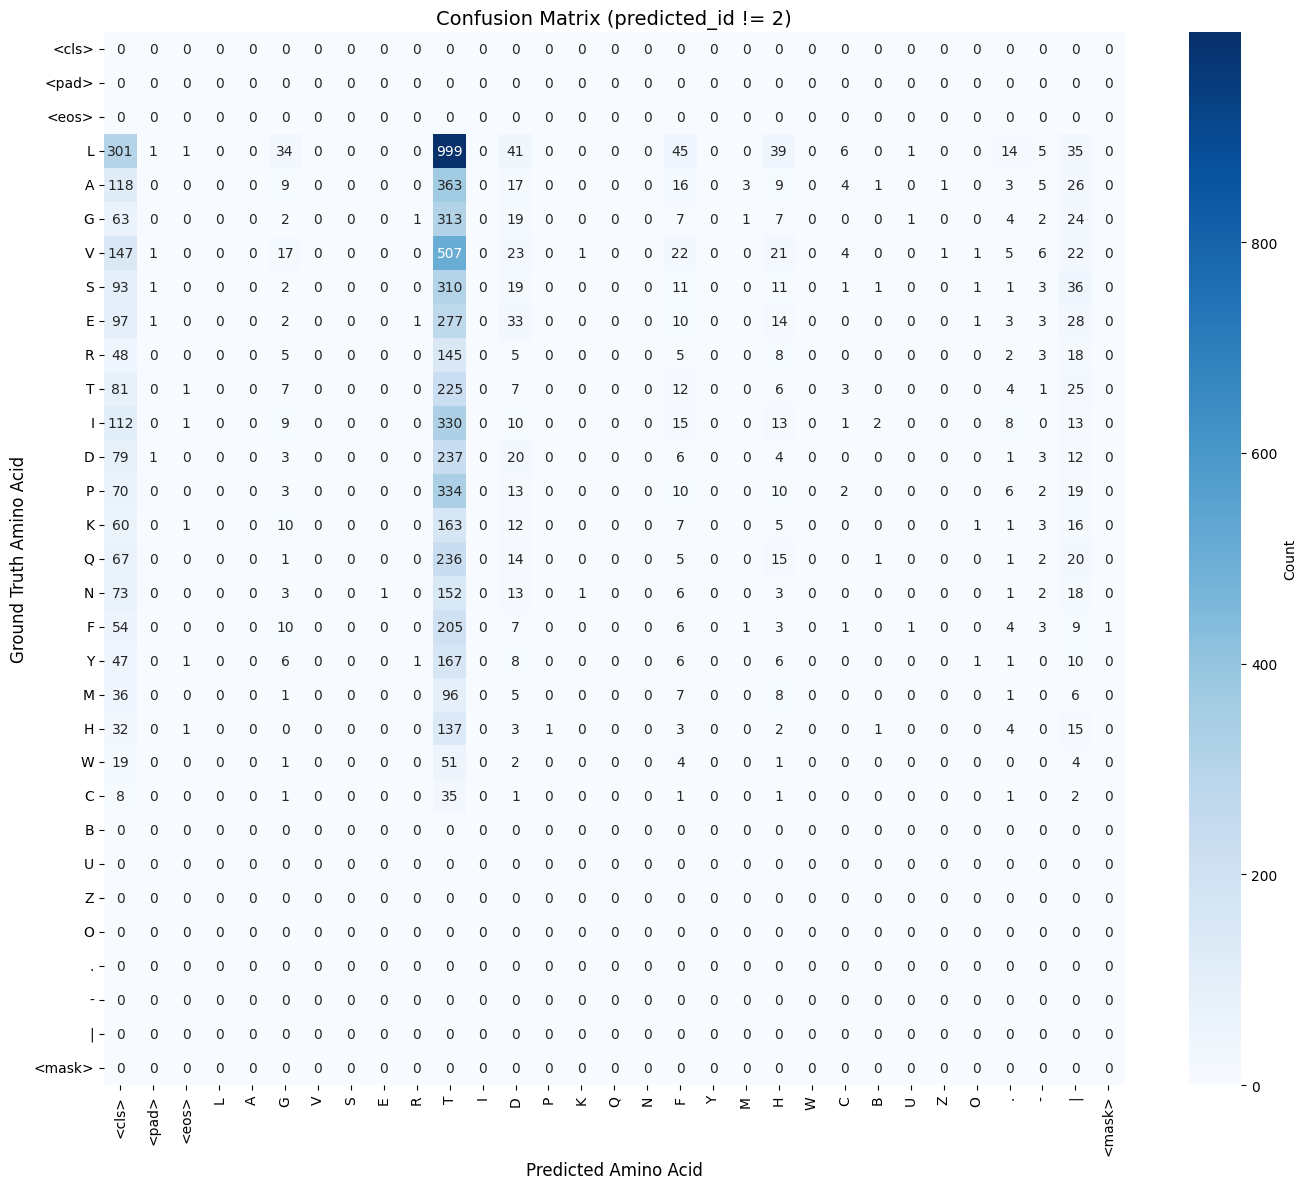

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Your filtered data
filtered_df = results_df2[(results_df2['ground_truth_id'] > 3) & (results_df2['position'] != 0)]

# Create mapping from token ID to amino acid
# If vocab is {token: id}, we need to invert it to {id: token}
if isinstance(base_model.tokenizer.vocab, dict):
    id_to_aa = {v: k for k, v in base_model.tokenizer.vocab.items()}
else:
    # If it's already a list/array where index = id
    id_to_aa = {i: aa for i, aa in enumerate(base_model.tokenizer.vocab)}

# Get unique labels
gt_ids = sorted(filtered_df['ground_truth_id'].unique())
pred_ids = sorted(filtered_df['predicted_id'].unique())
all_ids = sorted(set(gt_ids) | set(pred_ids))

# Map IDs to amino acids
labels = [id_to_aa.get(i, f'ID_{i}') for i in all_ids]

# Create confusion matrix
cm = confusion_matrix(filtered_df['ground_truth_id'], 
                     filtered_df['predicted_id'],
                     labels=all_ids)

# Plot
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Amino Acid', fontsize=12)
plt.ylabel('Ground Truth Amino Acid', fontsize=12)
plt.title('Confusion Matrix (predicted_id != 2)', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Your filtered data
filtered_df = results_df[(results_df['ground_truth_id'] > 3) & (results_df['position'] != 0)]

# Create mapping from token ID to amino acid
# If vocab is {token: id}, we need to invert it to {id: token}
if isinstance(base_model.tokenizer.vocab, dict):
    id_to_aa = {v: k for k, v in base_model.tokenizer.vocab.items()}
else:
    # If it's already a list/array where index = id
    id_to_aa = {i: aa for i, aa in enumerate(base_model.tokenizer.vocab)}

# Get unique labels
gt_ids = sorted(filtered_df['ground_truth_id'].unique())
pred_ids = sorted(filtered_df['predicted_id'].unique())
all_ids = sorted(set(gt_ids) | set(pred_ids))

# Map IDs to amino acids
labels = [id_to_aa.get(i) for i in all_ids]

# Create confusion matrix
cm = confusion_matrix(filtered_df['ground_truth_id'], 
                     filtered_df['predicted_id'],
                     labels=all_ids)

# Plot
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Amino Acid', fontsize=12)
plt.ylabel('Ground Truth Amino Acid', fontsize=12)
plt.title('Confusion Matrix (predicted_id != 2)', fontsize=14)
plt.tight_layout()
plt.show()

NameError: name 'results_df' is not defined

In [ ]:
results_df[results_df['position'] == 0]

,epitope,position,ground_truth_id,predicted_id,predicted_prob,true_token_prob
0,SLYGASPGL,0,8,2,1.0,0.000000e+00
11,RLVAVGLLGI,0,10,2,1.0,0.000000e+00
24,FIVEPTFTV,0,18,2,1.0,1.401298e-45
42,KLLDKNPFSV,0,15,2,1.0,0.000000e+00
48,LLLGDHQYYV,0,4,2,1.0,0.000000e+00
...,...,...,...,...,...,...
9967,GLPNDDLYI,0,6,2,1.0,4.929178e-24
9971,SVRDLLDTV,0,8,2,1.0,0.000000e+00
9979,ELTLELADIL,0,9,2,1.0,0.000000e+00
9993,VADKFTEL,0,7,2,1.0,0.000000e+00


In [ ]:
filtered_df['predicted_prob'].hist()
plt.yscale('log')
plt.show()

,epitope,position,ground_truth_id,predicted_id,predicted_prob,true_token_prob
1,SLYGASPGL,1,4,2,1.000000,0.000000e+00
2,SLYGASPGL,2,19,2,1.000000,0.000000e+00
3,SLYGASPGL,6,14,2,1.000000,0.000000e+00
4,FQNPQTHVIEN,4,16,2,1.000000,0.000000e+00
5,FQNPQTHVIEN,6,21,2,1.000000,5.144685e-19
...,...,...,...,...,...,...
10002,APGAPGPKAA,1,14,2,0.999987,0.000000e+00
10003,APGAPGPKAA,7,15,2,1.000000,0.000000e+00
10005,SILSNIHEV,2,4,2,0.999673,0.000000e+00
10006,SILSNIHEV,4,17,2,1.000000,0.000000e+00


In [ ]:
df_df7 = pd.read_csv('/global/scratch/users/sergiomar10/data/20122024_ESM_hlas.csv')
print(df_df7.shape)
df_df7.head()

(6650, 7)


,Sequence,Masked_Position,Target_AA,Predicted_AA,Predicted_Probability,Correct,length
0,K<mask>YQDTHQEY<eos><pad><pad><pad><pad><pad><...,2,L,L,0.080930,1,12
1,<mask>LYQDTHQEY<eos><pad><pad><pad><pad><pad><...,1,K,M,0.701874,0,12
2,KLYQ<mask>THQEY<eos><pad><pad><pad><pad><pad><...,5,D,L,0.102184,0,12
3,KLY<mask>DTHQEY<eos><pad><pad><pad><pad><pad><...,4,Q,L,0.101992,0,12
4,KLY<mask>DTHQEY<eos><pad><pad><pad><pad><pad><...,4,Q,L,0.101992,0,12


In [ ]:
df_df7

,Sequence,Masked_Position,Target_AA,Predicted_AA,Predicted_Probability,Correct,length
0,K<mask>YQDTHQEY<eos><pad><pad><pad><pad><pad><...,2,L,L,0.080930,1,12
1,<mask>LYQDTHQEY<eos><pad><pad><pad><pad><pad><...,1,K,M,0.701874,0,12
2,KLYQ<mask>THQEY<eos><pad><pad><pad><pad><pad><...,5,D,L,0.102184,0,12
3,KLY<mask>DTHQEY<eos><pad><pad><pad><pad><pad><...,4,Q,L,0.101992,0,12
4,KLY<mask>DTHQEY<eos><pad><pad><pad><pad><pad><...,4,Q,L,0.101992,0,12
...,...,...,...,...,...,...,...
6645,NCINNTI<mask>L<eos><pad><pad><pad><pad><pad><p...,8,A,L,0.103407,0,11
6646,<mask>CINNTIAL<eos><pad><pad><pad><pad><pad><p...,1,N,M,0.750119,0,11
6647,NCINNTI<mask>L<eos><pad><pad><pad><pad><pad><p...,8,A,L,0.103407,0,11
6648,NC<mask>NNTIAL<eos><pad><pad><pad><pad><pad><p...,3,I,N,0.087035,0,11


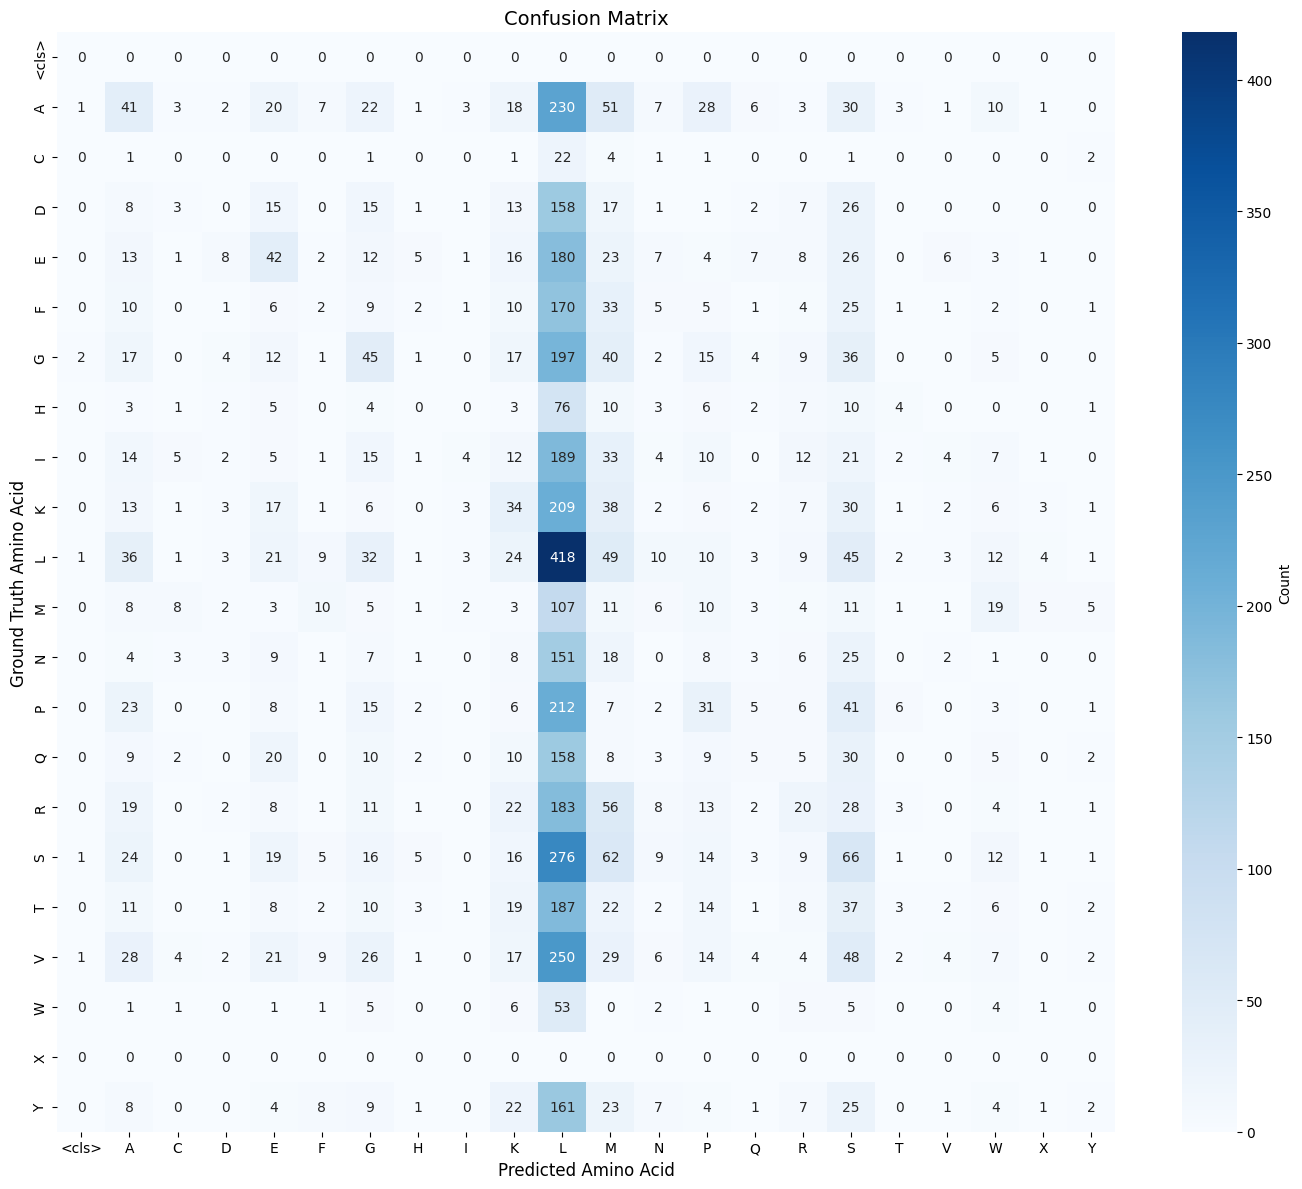

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Your filtered data
df_df7 = df_df7 #[(df_df7['original_aa'] > 3) & (df_df7['position'] != 0)]

# Create mapping from token ID to amino acid
# If vocab is {token: id}, we need to invert it to {id: token}
if isinstance(base_model.tokenizer.vocab, dict):
    id_to_aa = {v: k for k, v in base_model.tokenizer.vocab.items()}
else:
    # If it's already a list/array where index = id
    id_to_aa = {i: aa for i, aa in enumerate(base_model.tokenizer.vocab)}

# Get unique labels
gt_ids = sorted(df_df7['Target_AA'].unique())
pred_ids = sorted(df_df7['Predicted_AA'].unique())
all_ids = sorted(set(gt_ids) | set(pred_ids))

# Map IDs to amino acids
labels = all_ids#[id_to_aa.get(i) for i in all_ids]

# Create confusion matrix
cm = confusion_matrix(df_df7['Target_AA'], 
                     df_df7['Predicted_AA'],
                     labels=all_ids)

# Plot
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Amino Acid', fontsize=12)
plt.ylabel('Ground Truth Amino Acid', fontsize=12)
plt.title('Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
df_df7[df_df7['Masked_Position'] == 2]

,Sequence,Masked_Position,Target_AA,Predicted_AA,Predicted_Probability,Correct,length
0,K<mask>YQDTHQEY<eos><pad><pad><pad><pad><pad><...,2,L,L,0.080930,1,12
6,L<mask>LKTGVQF<eos><pad><pad><pad><pad><pad><p...,2,V,L,0.106103,0,11
8,L<mask>LKTGVQF<eos><pad><pad><pad><pad><pad><p...,2,V,L,0.106103,0,11
12,K<mask>IINVKQF<eos><pad><pad><pad><pad><pad><p...,2,Y,K,0.099077,0,11
34,S<mask>RQSDVMIVAGT<mask><eos><pad><pad><pad>,2,P,L,0.093695,0,16
...,...,...,...,...,...,...,...
6632,A<mask>NENMLTM<eos><pad><pad><pad><pad><pad><p...,2,S,N,0.457517,0,11
6637,E<mask>GINPNYL<eos><pad><pad><pad><pad><pad><p...,2,K,L,0.107996,0,11
6640,T<mask>PINPQHM<eos><pad><pad><pad><pad><pad><p...,2,S,P,0.102349,0,11
6642,T<mask>PINPQHM<eos><pad><pad><pad><pad><pad><p...,2,S,P,0.102349,0,11


In [ ]:
# first_batch = next(iter(eval_loader))

# # Unpack 5 elements
# input_ids, attention_mask, labels, raw_sequences, positions = first_batch

# print("Batch size:", input_ids.shape[0])
# print("\nFirst sample in batch:")
# print("Input IDs shape:", input_ids[0].shape)
# print("Input IDs:", input_ids[0])
# print("\nAttention mask:", attention_mask[0])
# print("\nLabels:", labels[0])
# print("\nRaw sequence:", raw_sequences[0])
# print("\nPosition to mask:", positions[0])

In [ ]:
break

In [ ]:

#########################################################
# Create DataLoaders
#########################################################
base_model = model_masked.base_model

# Repeat train_seqs for data augmentation
train_seqs = train_seqs * num_augmentations

batch_size = 8

eval_loader = get_mlm_dataloader(
    eval_seqs, base_model, batch_size=batch_size,
    shuffle=False, max_length=max_length, max_length_hla=max_length_hla
)

In [ ]:
#########################################################
# Training and Validation Loops
#########################################################
num_epochs = 10

# Simple function to measure MLM accuracy on masked positions
def evaluate_mlm_accuracy(loader):
    """Compute how often the model guesses the correct token for the masked tokens."""
    model_masked.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for input_ids, attention_mask, labels, _ in loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            # Forward
            logits = base_model(input_ids, attention_mask)  # [batch_size, seq_len, vocab_size]
            # We only compare at positions where labels != -100
            mask_positions = (labels != 1)
            if not mask_positions.any():
                continue

            # Predictions
            preds = torch.argmax(logits, dim=-1)  # [batch_size, seq_len]
            correct += (preds[mask_positions] == labels[mask_positions]).sum().item()
            total += mask_positions.sum().item()

    model_masked.train()
    return correct / total if total > 0 else 0.0

In [ ]:
import math

model_masked.eval()
eval_results = []
total_nll = 0.0
total_tokens = 0

with torch.no_grad():
    for input_ids, attention_mask, labels, raw_epitopes in eval_loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        logits = base_model(input_ids, attention_mask)
        logits = logits.sequence_logits
        
        # Compute softmax probabilities and log probabilities
        probs = F.softmax(logits, dim=-1)
        log_probs = F.log_softmax(logits, dim=-1)
        preds = torch.argmax(probs, dim=-1)

        for b in range(input_ids.size(0)):
            # Grab the actual epitope string for this sample
            epitope_seq = raw_epitopes[b]

            # Identify valid positions (for example, positions that are not padding; here, labels[b]!=1)
            valid_positions = torch.where(labels[b] != 1)[0]
            
            for pos in valid_positions:
                pos = pos.item()
                original_id = labels[b, pos].item()
                pred_id = preds[b, pos].item()
                pred_prob = probs[b, pos, pred_id].item()

                # Compute the negative log likelihood for this token and its perplexity
                token_log_prob = log_probs[b, pos, original_id]
                token_nll = -token_log_prob.item()
                token_perplexity = math.exp(token_nll)

                total_nll += token_nll
                total_tokens += 1

                original_aa = base_model.tokenizer.decode([original_id]).strip()
                predicted_aa = base_model.tokenizer.decode([pred_id]).strip()

                eval_results.append({
                    "batch_index": b,
                    "epitope": epitope_seq,
                    "position": pos,
                    "original_aa": original_aa,
                    "predicted_aa": predicted_aa,
                    "predicted_prob": pred_prob,
                    "token_perplexity": token_perplexity  # Per-token perplexity
                })

# # Compute global perplexity over all valid tokens
# if total_tokens > 0:
#     avg_nll = total_nll / total_tokens
#     global_perplexity = math.exp(avg_nll)
# else:
#     global_perplexity = float('inf')

# print(f"Global Perplexity: {global_perplexity:.4f}")

# # Save evaluation predictions to CSV
# eval_df = pd.DataFrame(eval_results)
# eval_save_dir = "/global/scratch/users/sergiomar10/data/ESMC_Pretrain"
# os.makedirs(eval_save_dir, exist_ok=True)
# eval_csv_path = os.path.join(eval_save_dir, f"{name_of_model}.csv")
# eval_df.to_csv(eval_csv_path, index=False)
# print(f"Evaluation predictions saved to {eval_csv_path}", flush=True)


In [ ]:
eval_df = pd.DataFrame(eval_results)

In [ ]:
eval_df['length'] = eval_df['epitope'].apply(len)

In [ ]:
eval_df.loc[:, ['length', 'predicted_prob']].groupby('length').min().reset_index()

,length,predicted_prob
0,8,0.104474
1,9,0.079255
2,10,0.081328
3,11,0.094776
4,12,0.087491
5,16,0.099257
6,20,0.103440


In [ ]:
from collections import Counter
Counter(eval_df['length'])

Counter({9: 780, 10: 317, 11: 10, 16: 5, 8: 5, 12: 2, 20: 1})

<Axes: >

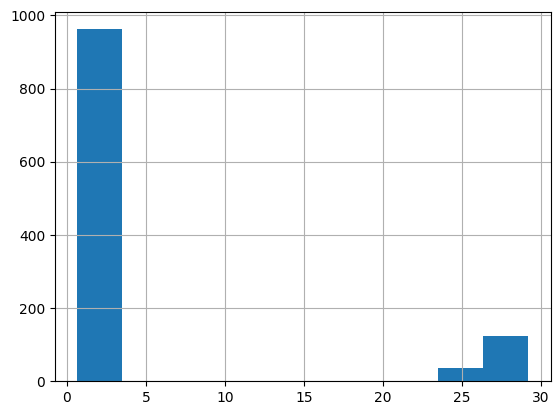

In [ ]:
np.log10(eval_df['token_perplexity']).hist()